In [ ]:
# src/model.py
# Model Development and Knowledge-Gap Inference

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
class KnowledgeGapModel:
    """Lightweight Explainable Model for Knowledge Gap Detection"""
    
    def __init__(self, max_depth=5, random_state=42):
        self.model = DecisionTreeClassifier(
            max_depth=max_depth, 
            random_state=random_state,
            min_samples_split=10,
            min_samples_leaf=5
        )
        self.feature_names = None
        self.is_trained = False
    
    def prepare_data(self, feature_df: pd.DataFrame):
        """Prepare features and target for training"""
        # Drop non-feature columns
        drop_cols = ['student_id', 'concept', 'knowledge_gap', 'final_result']
        feature_cols = [col for col in feature_df.columns if col not in drop_cols]
        
        self.feature_names = feature_cols
        X = feature_df[feature_cols]
        y = feature_df['knowledge_gap']
        
        print(f"Features used: {len(feature_cols)}")
        print(f"Target distribution:\n{y.value_counts()}")
        
        return X, y, feature_cols
    
    def train(self, feature_df: pd.DataFrame, test_size=0.25):
        """Train the Decision Tree model"""
        print("Training lightweight Decision Tree model...")
        
        X, y, feature_cols = self.prepare_data(feature_df)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        self.model.fit(X_train, y_train)
        self.is_trained = True
        
        # Evaluate
        y_pred = self.model.predict(X_test)
        
        print("\n=== MODEL PERFORMANCE ===")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['No Gap', 'Knowledge Gap']))
        
        # Feature Importance
        importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\nTop 10 Most Important Features:")
        print(importance.head(10))
        
        self.feature_importance = importance
        return X_test, y_test, y_pred
    
    def predict_gaps(self, feature_df: pd.DataFrame) -> pd.DataFrame:
        """Predict knowledge gaps for all student-concept pairs"""
        if not self.is_trained:
            raise ValueError("Model must be trained first!")
        
        X, _, _ = self.prepare_data(feature_df)
        feature_df = feature_df.copy()
        
        feature_df['gap_probability'] = self.model.predict_proba(X)[:, 1]
        feature_df['predicted_gap'] = self.model.predict(X)
        
        return feature_df
    
    def get_gap_summary(self, predictions_df: pd.DataFrame) -> pd.DataFrame:
        """Create student-level knowledge gap summary"""
        summary = predictions_df.groupby('student_id').agg(
            total_concepts=('concept', 'nunique'),
            concepts_with_gaps=('predicted_gap', 'sum'),
            avg_gap_probability=('gap_probability', 'mean'),
            max_gap_probability=('gap_probability', 'max')
        ).reset_index()
        
        summary['gap_percentage'] = (summary['concepts_with_gaps'] / summary['total_concepts'] * 100).round(1)
        summary['risk_level'] = pd.cut(
            summary['avg_gap_probability'],
            bins=[0, 0.3, 0.6, 1.0],
            labels=['Low', 'Medium', 'High']
        )
        
        return summary
    
    def plot_feature_importance(self, top_n=10):
        """Visualize feature importance"""
        if not hasattr(self, 'feature_importance'):
            print("Train model first!")
            return
        
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=self.feature_importance.head(top_n), 
            x='importance', 
            y='feature'
        )
        plt.title('Top Features Contributing to Knowledge Gap Prediction')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
    
    def save_model(self, path="models/knowledge_gap_model.joblib"):
        """Save trained model"""
        import joblib
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump(self.model, path)
        print(f"Model saved to {path}")

=== DAY 4: Training Knowledge Gap Model ===

Loading OULAD studentVle.csv (large file - using efficient loading)...
✅ Loaded 180,982 interaction records from AAA-2013J
✅ Enriched with activity_type from vle.csv
✅ Standardized DataFrame: 180,982 rows
Columns: ['student_id', 'timestamp', 'num_interactions', 'activity_type', 'concept']
Starting preprocessing...
Preprocessed data: 180,982 rows
Extracting features per student and per concept...
✅ Extracted 13 features for 378 students
Target distribution:
knowledge_gap
0    278
1    105
Name: count, dtype: int64

🎉 Feature Engineering Complete!
Final feature shape: (2646, 15)
Sample columns: ['student_id', 'concept', 'total_interactions', 'unique_days_active', 'avg_interactions_per_day', 'first_interaction_day', 'last_interaction_day', 'span_days', 'max_daily_clicks', 'interaction_consistency']
Training lightweight Decision Tree model...
Features used: 11
Target distribution:
knowledge_gap
0    1985
1     661
Name: count, dtype: int64

=== 

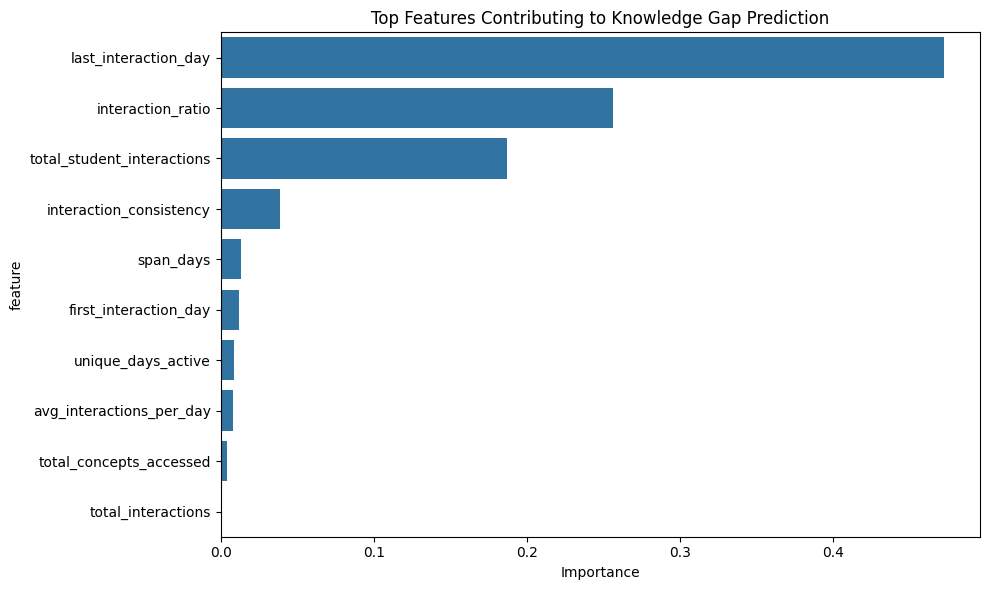


🎉 DAY 4 SUCCESS! Model trained and knowledge gaps inferred.


In [3]:
# ========================== QUICK TEST ==========================
if __name__ == "__main__":
    from src.ingestion import LogIngestion
    from src.features import FeatureEngineer
    import pandas as pd
    
    print("=== DAY 4: Training Knowledge Gap Model ===\n")
    
    # Load data
    ingestor = LogIngestion()
    raw = ingestor.load_oulad_vle()
    enriched = ingestor.enrich_with_activity_type(raw)
    std_df = ingestor.standardize_logs(enriched)
    
    # Feature Engineering
    engineer = FeatureEngineer()
    student_info = pd.read_csv("data/studentInfo.csv")
    student_info = student_info[(student_info['code_module'] == 'AAA') & 
                               (student_info['code_presentation'] == '2013J')]
    
    feature_df = engineer.build_full_feature_set(std_df, student_info)
    
    # Train Model
    model = KnowledgeGapModel(max_depth=5)
    X_test, y_test, y_pred = model.train(feature_df)
    
    # Predict gaps
    predictions = model.predict_gaps(feature_df)
    summary = model.get_gap_summary(predictions)
    
    print("\nStudent Risk Summary Sample:")
    print(summary.head(10))
    
    model.plot_feature_importance()
    
    print("\n🎉 DAY 4 SUCCESS! Model trained and knowledge gaps inferred.")

In [4]:
# 04_model_test.ipynb

from src.ingestion import LogIngestion
from src.features import FeatureEngineer
from src.model import KnowledgeGapModel
import pandas as pd

print("=== DAY 4: Model Development & Knowledge-Gap Inference ===\n")

# 1. Load and process data
ingestor = LogIngestion()
raw = ingestor.load_oulad_vle()
enriched = ingestor.enrich_with_activity_type(raw)
std_df = ingestor.standardize_logs(enriched)

# 2. Feature Engineering
engineer = FeatureEngineer()
student_info = pd.read_csv("data/studentInfo.csv")
student_info = student_info[(student_info['code_module'] == 'AAA') & 
                           (student_info['code_presentation'] == '2013J')]

feature_df = engineer.build_full_feature_set(std_df, student_info)

# 3. Train Model
model = KnowledgeGapModel(max_depth=5)
X_test, y_test, y_pred = model.train(feature_df)

# 4. Generate Predictions and Summary
predictions = model.predict_gaps(feature_df)
summary = model.get_gap_summary(predictions)

print("\n=== KNOWLEDGE GAP SUMMARY ===")
print(summary.sort_values('gap_percentage', ascending=False).head(10))

print("\n🎉 DAY 4 SUCCESS! The core model is now working.")

=== DAY 4: Model Development & Knowledge-Gap Inference ===

Loading OULAD studentVle.csv (large file - using efficient loading)...
✅ Loaded 180,982 interaction records from AAA-2013J
✅ Enriched with activity_type from vle.csv
✅ Standardized DataFrame: 180,982 rows
Columns: ['student_id', 'timestamp', 'num_interactions', 'activity_type', 'concept']
Starting preprocessing...
Preprocessed data: 180,982 rows
Extracting features per student and per concept...
✅ Extracted 13 features for 378 students
Target distribution:
knowledge_gap
0    278
1    105
Name: count, dtype: int64

🎉 Feature Engineering Complete!
Final feature shape: (2646, 15)
Sample columns: ['student_id', 'concept', 'total_interactions', 'unique_days_active', 'avg_interactions_per_day', 'first_interaction_day', 'last_interaction_day', 'span_days', 'max_daily_clicks', 'interaction_consistency']
Training lightweight Decision Tree model...
Features used: 11
Target distribution:
knowledge_gap
0    1985
1     661
Name: count, dty